**24BAD405 - NISHANTH P**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import os

## 1. Load the SMS Spam Dataset

In [2]:
# Load dataset from data/spam.csv
df = pd.read_csv('../data/spam.csv', encoding='latin-1')

# Data Cleaning: Remove unnecessary columns and rename
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df.columns = ['label', 'message']

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Data Preprocessing

- Text cleaning (lowercase, punctuation removal)
- Stopword removal
- Label Encoding

In [3]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = "".join([char for char in text if char not in string.punctuation])
    # Tokenize
    tokens = nltk.word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_message'] = df['message'].apply(clean_text)

# Encode target labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label']) # ham: 0, spam: 1

df[['message', 'clean_message', 'label', 'label_encoded']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nisha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nisha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nisha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,message,clean_message,label,label_encoded
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,ham,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ham,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...,spam,1
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say,ham,0
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though,ham,0


## 3. Feature Extraction & Train-Test Split

Converting text into numerical features using TF-IDF Vectorization.

In [4]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['clean_message'])
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (4457, 9372)
X_test shape: (1115, 9372)


## 4. Train Multinomial Naive Bayes Classifier

In [5]:
clf = MultinomialNB(alpha=1.0) # alpha=1.0 is Laplace smoothing
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Model trained and predictions made.")

Model trained and predictions made.


## 5. Evaluate Performance

In [6]:
print("Performance Evaluation Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Performance Evaluation Metrics:
Accuracy:  0.9659
Precision: 1.0000
Recall:    0.7467
F1 Score:  0.8550

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



## 6. Visualizations

### Confusion Matrix

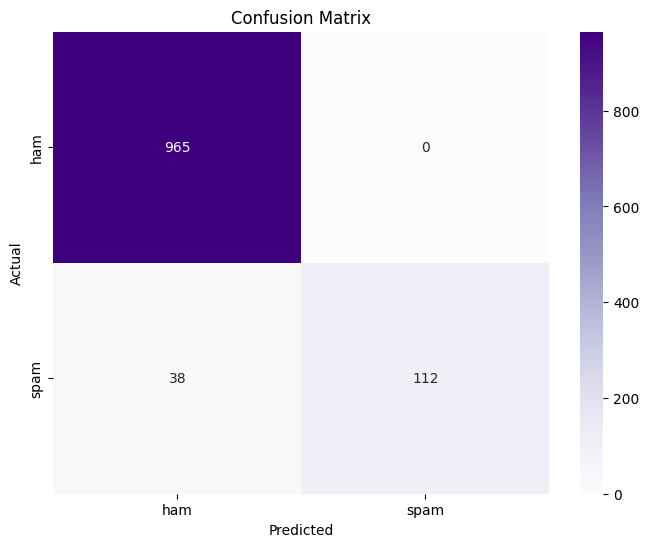

In [7]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Laplace Smoothing Impact

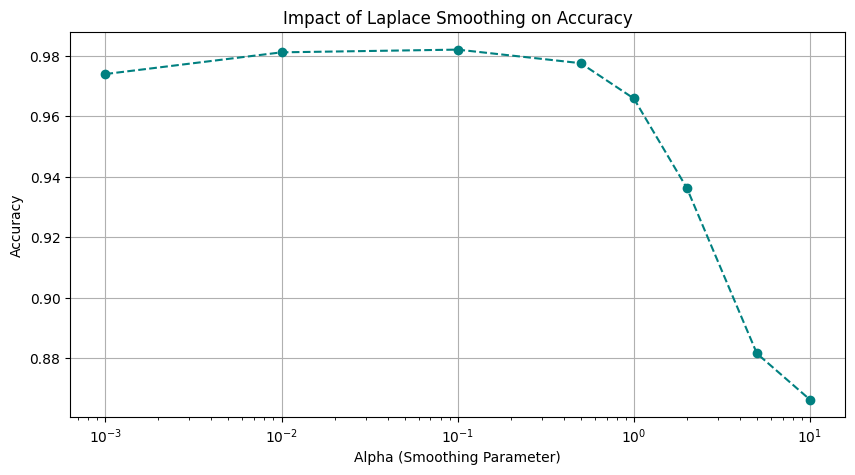

In [8]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
results = []
for alpha in alphas:
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train, y_train)
    results.append(model.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(alphas, results, marker='o', linestyle='--', color='teal')
plt.xscale('log')
plt.xlabel('Alpha (Smoothing Parameter)')
plt.ylabel('Accuracy')
plt.title('Impact of Laplace Smoothing on Accuracy')
plt.grid(True)
plt.show()

### Word Frequency Comparison (Top 20 Words)

C:\Users\nisha\AppData\Local\Temp\ipykernel_2744\3650796590.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[x[1] for x in spam_counts], y=[x[0] for x in spam_counts], ax=ax1, palette='rocket')
C:\Users\nisha\AppData\Local\Temp\ipykernel_2744\3650796590.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[x[1] for x in ham_counts], y=[x[0] for x in ham_counts], ax=ax2, palette='mako')


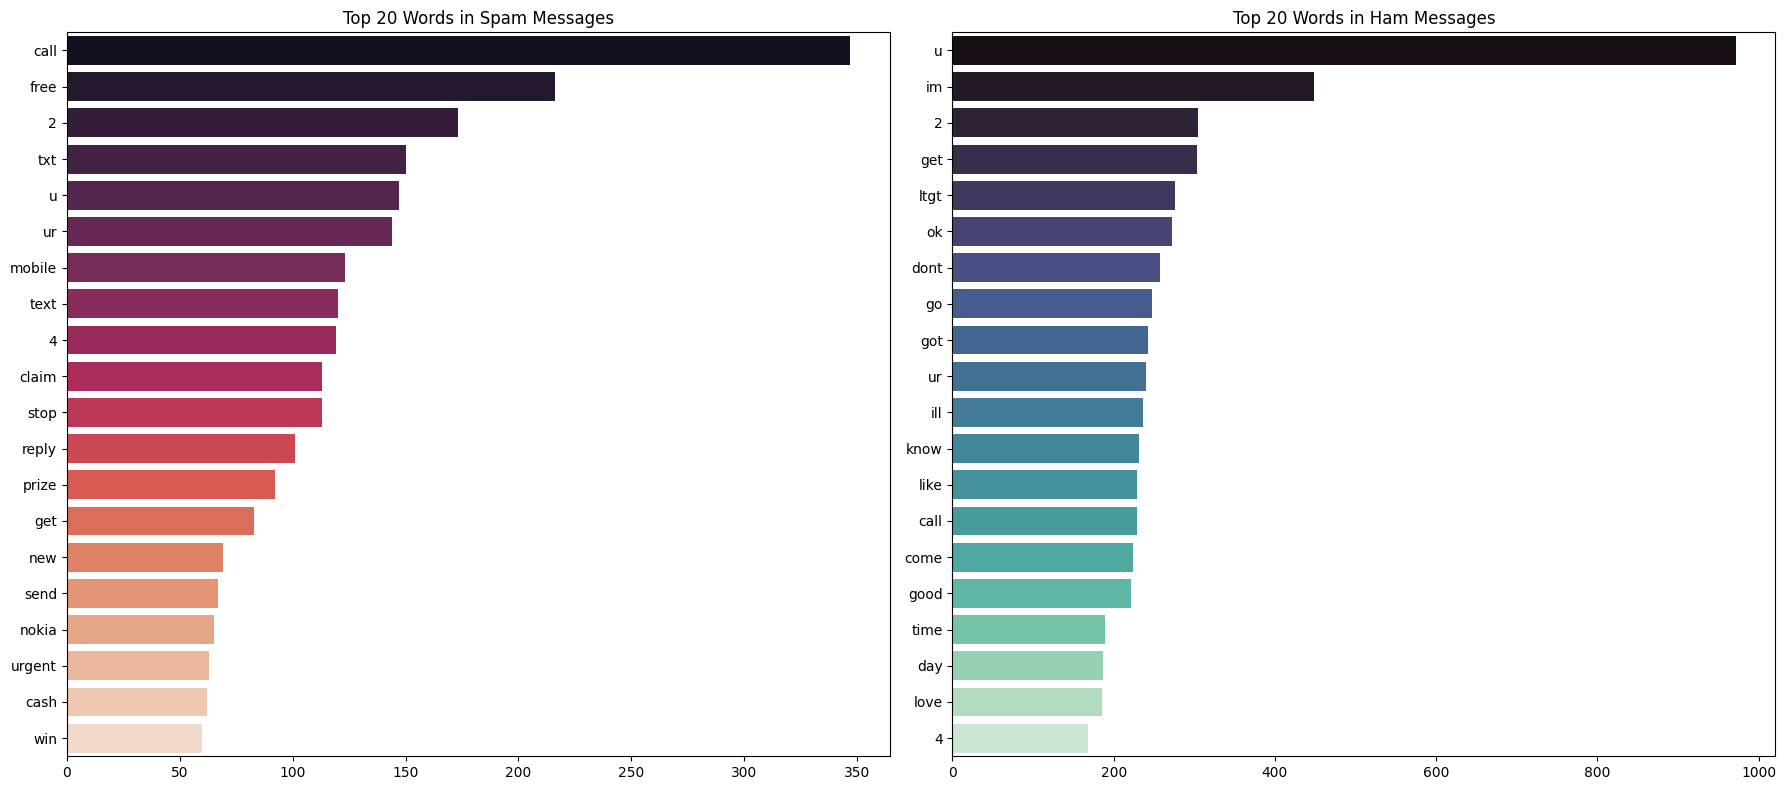

In [9]:
from collections import Counter

spam_words = " ".join(df[df['label_encoded']==1]['clean_message']).split()
ham_words = " ".join(df[df['label_encoded']==0]['clean_message']).split()

spam_counts = Counter(spam_words).most_common(20)
ham_counts = Counter(ham_words).most_common(20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(x=[x[1] for x in spam_counts], y=[x[0] for x in spam_counts], ax=ax1, palette='rocket')
ax1.set_title('Top 20 Words in Spam Messages')

sns.barplot(x=[x[1] for x in ham_counts], y=[x[0] for x in ham_counts], ax=ax2, palette='mako')
ax2.set_title('Top 20 Words in Ham Messages')

plt.tight_layout()
plt.show()

## 7. Analyze Misclassified Examples

In [10]:
test_indices = y_test.index
misclassified_indices = test_indices[y_test != y_pred]
misclassified_df = df.loc[misclassified_indices].copy()
misclassified_df['predicted'] = le.inverse_transform(y_pred[y_test != y_pred])
misclassified_df['actual'] = le.inverse_transform(y_test[y_test != y_pred])

print(f"Total misclassified: {len(misclassified_df)}")
misclassified_df[['message', 'actual', 'predicted']].head(10)

Total misclassified: 38


,message,actual,predicted
1044,We know someone who you know that fancies you....,spam,ham
683,Hi I'm sue. I am 20 years old and work as a la...,spam,ham
15,"XXXMobileMovieClub: To use your credit, click ...",spam,ham
4071,Loans for any purpose even if you have Bad Cre...,spam,ham
2312,tddnewsletter@emc1.co.uk (More games from TheD...,spam,ham
3979,ringtoneking 84484,spam,ham
2877,Hey Boys. Want hot XXX pics sent direct 2 ur p...,spam,ham
3562,Auction round 4. The highest bid is now å£54. ...,spam,ham
1268,Can U get 2 phone NOW? I wanna chat 2 set up m...,spam,ham
730,Email AlertFrom: Jeri StewartSize: 2KBSubject:...,spam,ham


## 8. Feature Importance (Top Spam/Ham words)

In [11]:
feature_names = np.array(tfidf.get_feature_names_out())
spam_class_prob_sorted = clf.feature_log_prob_[1].argsort()[::-1]
ham_class_prob_sorted = clf.feature_log_prob_[0].argsort()[::-1]

print("Top 15 Words Influencing Spam Classification:")
print(feature_names[spam_class_prob_sorted[:15]])

print("\nTop 15 Words Influencing Ham Classification:")
print(feature_names[ham_class_prob_sorted[:15]])

Top 15 Words Influencing Spam Classification:
['call' 'free' 'txt' 'mobile' 'claim' 'prize' 'ur' 'stop' 'text' 'reply'
 'urgent' 'new' 'cash' 'nokia' 'please']

Top 15 Words Influencing Ham Classification:
['ok' 'im' 'ill' 'come' 'get' 'ltgt' 'call' 'got' 'dont' 'go' 'good'
 'home' 'know' 'sorry' 'time']
